In [1]:
import numpy as np
import os
# Check existing data
data = np.load('F13_smallN_data.npz', allow_pickle=True)
print(data.files)


FileNotFoundError: [Errno 2] No such file or directory: 'F13_smallN_data.npz'

In [2]:
import subprocess
result = subprocess.run(['find', '/workspace', '-name', 'F13_smallN_data.npz', '-type', 'f'], capture_output=True, text=True)
print(result.stdout)
print('---')
result2 = subprocess.run(['ls', '-la', '.'], capture_output=True, text=True)
print(result2.stdout)



---
total 210
drwxrwsr-x 5 root jupytergroup 4096 May 9 11:25 .
drwxr-xr-x 5 root root 4096 May 9 11:25 ..
drwxrwsr-x 5 root jupytergroup 4096 May 9 11:25 .config
-rw-rw-r-- 1 kerneluser jupytergroup 0 May 9 11:25 .kernel_llm_logs_1.txt
drwxrwsr-x 2 root jupytergroup 4096 May 9 11:25 .prompts
-rw-r--r-- 1 root jupytergroup 136 May 9 11:25 H_complex_F13.npy
-rw-r--r-- 1 root jupytergroup 100702 May 9 11:25 v6 — Binding Context Document.pdf
-rw-r--r-- 1 root jupytergroup 136 May 9 11:25 N.npy
-rw-r--r-- 1 root jupytergroup 25728 May 9 11:25 S_F13.npy
-rw-r--r-- 1 root jupytergroup 16128 May 9 11:25 a_F13.npy
-rw-r--r-- 1 root jupytergroup 8128 May 9 11:25 boot_H_F13.npy
-rw-r--r-- 1 root jupytergroup 8128 May 9 11:25 boot_H_F14.npy
-rw-r--r-- 1 root jupytergroup 8128 May 9 11:25 boot_pc1_F13.npy
-rw-r--r-- 1 root jupytergroup 8128 May 9 11:25 boot_pc1_F14.npy
-rw-r--r-- 1 root jupytergroup 184 May 9 11:25 feature_H.npy
-rw-r--r-- 1 root jupytergroup 184 May 9 11:25 feature_H_H.npy
-rw-r

In [3]:
a_F13 = np.load('a_F13.npy')
print('a_F13 shape:', a_F13.shape, 'dtype:', a_F13.dtype)
print('First 20:', a_F13[:20])
print('a[1] =', a_F13[1])
r = np.load('spectral_param_r.npy')
print('r =', r)
N_val = np.load('N.npy')
print('N =', N_val)
lmfdb = np.load('lmfdb_label.npy')
print('lmfdb_label:', lmfdb)


a_F13 shape: (1000,) dtype: complex128
First 20: [ 0. +0.j 1. +0.j -1.06833355+0.j -0.45619735+0.j
 0.14133658+0.j -0.29067255+0.j 0.48737094+0.j -0.74494161+0.j
 0.91733894+0.j -0.79188397+0.j 0.31053524+0.j 0.1661636 +0.j
 -0.06447737+0.j -0.58668853+0.j 0.79584612+0.j 0.13260405+0.j
 -1.12136055+0.j 0.5706958 +0.j 0.84599622+0.j -0.98193859+0.j]
a[1] = (1+0j)
r = 9.533695261353557
N = 999
lmfdb_label: 1.0.1.1.1


In [4]:
# a_F13[0] is 0 (1-indexed convention), a_F13[1] = 1 (lambda_f(1)), then a_F13[2] = lambda_f(2) = -1.0683...
# r = 9.5337..., spectral parameter
# We need lambda_f(p) values. These cannot be derived directly from r alone — they are specific eigenvalues for primes
# determined by numerical solution of the Maass form. For an SL(2,Z) Maass form, lambda_f(p) for each prime is computed
# from the Hecke eigenvalue equation. But we have the first 1000 coefficients (n up to 999).
# 
# Strategy: extract lambda_f(p) for primes p < 1000 from a_F13. For primes p in [1000, 10^6], we lack data.
# Actually: a_F13 contains lambda_f(n) for n in 1..999. So we know lambda_f(p) for primes p <= 997.
# But to compute lambda_f(n) for n up to 10^6, we need lambda_f(p) for ALL primes up to 10^6.
# Without those primes, we cannot extend to N=10^6 from this data alone.
# 
# We need to get the additional prime eigenvalues from LMFDB.

# First, verify multiplicativity using the small-N data
import sympy
# Check lambda(2)*lambda(3) = lambda(6)?
print('lambda(2)*lambda(3) =', a_F13[2] * a_F13[3])
print('lambda(6) =', a_F13[6])
print('lambda(2)^2 - 1 = lambda(4)?', a_F13[2]**2 - 1, 'vs', a_F13[4])
print('lambda(2)*lambda(4) - lambda(2) = lambda(8)?', a_F13[2]*a_F13[4] - a_F13[2], 'vs', a_F13[8])


lambda(2)*lambda(3) = (0.4873709344260925-0j)
lambda(6) = (0.48737094+0j)
lambda(2)^2 - 1 = lambda(4)? (0.14133657405560252-0j) vs (0.14133658+0j)
lambda(2)*lambda(4) - lambda(2) = lambda(8)? (0.917338939743741+0j) vs (0.91733894+0j)


In [5]:
# Recurrences confirmed. The coefficients are real-valued (stored as complex with 0 imag).
# Now: we need lambda_f(p) for all primes p up to 10^6.
# We have lambda_f(p) for primes p <= 997 from a_F13.
# Source: LMFDB has the first Maass form, label 1.0.1.1.1, but they typically only store ~ first 1000 coefficients.
# 
# Let me check what LMFDB/lfunction's API provides.

# First count primes below 10^6
primes = list(sympy.primerange(2, 10**6))
print('Number of primes up to 10^6:', len(primes))
primes_under_1000 = [p for p in primes if p < 1000]
print('Primes under 1000:', len(primes_under_1000))


Number of primes up to 10^6: 78498
Primes under 1000: 168


In [6]:
# We need ~78500 prime eigenvalues. Only 168 are in our local data.
# This is the crux. We need to either:
# (a) Compute lambda_f(p) from the spectral parameter r ≈ 9.5337 — but for Maass forms, there is NO closed form.
# The eigenvalues are only obtainable by numerical computation of the Maass form (Hejhal/Stromberg algorithm).
# (b) Download from LMFDB, which may host more coefficients for this form.

# Let me check LMFDB API for Maass form 1.0.1.1.1
import urllib.request
try:
 url = 'https://www.lmfdb.org/api/maass_newforms/?_format=json&maass_id=1_0_1.0.1.1.1'
 req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
 with urllib.request.urlopen(req, timeout=30) as resp:
 content = resp.read()[:2000]
 print(content.decode('utf-8', errors='replace'))
except Exception as e:
 print('Error:', e)


{
 "table": "maass_newforms",
 "timestamp": "2026-05-09T11:25:59.440737",
 "data": [],
 "start": 0,
 "offset": 0,
 "query": "/api/maass_newforms/?_format=json&maass_id=1_0_1.0.1.1.1&_offset=0",
 "next": "/api/maass_newforms/?_format=json&maass_id=1_0_1.0.1.1.1&_offset=0",
 "rec_id": "maass_id"
}


In [7]:
# Let's check the L-functions table for this Maass form. The corresponding L-function should have an LMFDB label.
# label 1.0.1.1.1 means: degree 1, level 1, etc... actually for Maass forms LMFDB uses a different scheme.
# Let me look at the Maass form with spectral parameter r ≈ 9.5337 (the first even Maass form on SL(2,Z))

import urllib.request
url = 'https://www.lmfdb.org/api/maass_newforms/?_format=json&level=1&_limit=5'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req, timeout=30) as resp:
 content = resp.read()
 print(content.decode('utf-8', errors='replace')[:3000])


{
 "table": "maass_newforms",
 "timestamp": "2026-05-09T11:26:06.816368",
 "data": [
 {
 "id": 48,
 "conrey_index": 1,
 "contributor": "Holger Then",
 "error": {
 "__RealLiteral__": 0,
 "data": "0.000000000024393456323874634",
 "prec": 97
 },
 "fricke_eigenvalue": 1,
 "level": 1,
 "maass_id": "4cb8503a58bca91458000032",
 "spectral_parameter": {
 "__RealLiteral__": 0,
 "data": "9.53369526135",
 "prec": 44
 },
 "symmetry": -1,
 "weight": 0
 },
 {
 "id": 49,
 "conrey_index": 1,
 "contributor": "Holger Then",
 "error": {
 "__RealLiteral__": 0,
 "data": "0.0000000004657229714784476",
 "prec": 90
 },
 "fricke_eigenvalue": 1,
 "level": 1,
 "maass_id": "4cb8503a58bca91458000033",
 "spectral_parameter": {
 "__RealLiteral__": 0,
 "data": "12.1730083247",
 "prec": 44
 },
 "symmetry": -1,
 "weight": 0
 },
 {
 "id": 0,
 "conrey_index": 1,
 "contributor": "Holger Then",
 "error": {
 "__RealLiteral__": 0,
 "data": "0.0000000008681467627827469",
 "prec": 90
 },
 "fricke_eigenvalue": 1,
 "level": 1,
 "

In [8]:
# Wait — the first listed has symmetry=-1 (odd) with r=9.5337. But the research objective states "first EVEN Maass form" with r≈9.5337.
# Hmm. Let me check the convention. In LMFDB's table maybe symmetry=1 is even and -1 is odd. The third entry is symmetry=1, r=13.7797 — which is the first even Maass form on SL(2,Z).
# 
# But our local data has r=9.5337, lmfdb_label '1.0.1.1.1'. The objective text says r≈9.5337 is the first even.
# Actually in LMFDB: symmetry +1 means even, -1 means odd. So r=13.7797 would be first even. But Booker-Stromberg literature says r ≈ 9.533 is the FIRST Maass cusp form on SL(2,Z) (which is odd).
# 
# Regardless: the user has stated r ≈ 9.5337 as the spectral parameter and we have validated coefficients in a_F13. So we proceed with that r value, regardless of the "even" terminology issue.

# Now: does LMFDB store coefficients (a_n) for this Maass form?
# Look at the maass_id 4cb8503a58bca91458000032 — fetch its detail page
url = 'https://www.lmfdb.org/api/maass_newforms/?_format=json&maass_id=4cb8503a58bca91458000032'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req, timeout=30) as resp:
 print(resp.read().decode('utf-8', errors='replace')[:3000])


{
 "table": "maass_newforms",
 "timestamp": "2026-05-09T11:26:19.496657",
 "data": [
 {
 "id": 48,
 "conrey_index": 1,
 "contributor": "Holger Then",
 "error": {
 "__RealLiteral__": 0,
 "data": "0.000000000024393456323874634",
 "prec": 97
 },
 "fricke_eigenvalue": 1,
 "level": 1,
 "maass_id": "4cb8503a58bca91458000032",
 "spectral_parameter": {
 "__RealLiteral__": 0,
 "data": "9.53369526135",
 "prec": 44
 },
 "symmetry": -1,
 "weight": 0
 }
 ],
 "start": 0,
 "offset": 1,
 "query": "/api/maass_newforms/?_format=json&maass_id=4cb8503a58bca91458000032&_offset=0",
 "next": "/api/maass_newforms/?_format=json&maass_id=4cb8503a58bca91458000032&_offset=1",
 "rec_id": "maass_id"
}


In [9]:
# Check if coefficients are available via a separate table — maass_rigor or maass_an_data table on LMFDB
# Look at all tables
url = 'https://www.lmfdb.org/api/'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req, timeout=30) as resp:
 text = resp.read().decode('utf-8', errors='replace')
# search for maass-related
import re
matches = re.findall(r'maass[a-z_]*', text)
print(set(matches))


{'maass_newforms_coefficients', 'maass_portraits', 'maass_rigor_coefficients', 'maass_rigor_portraits', 'maass_newforms', 'maass', 'maass_rigor'}


In [10]:
# Great! Try maass_newforms_coefficients
url = 'https://www.lmfdb.org/api/maass_newforms_coefficients/?_format=json&maass_id=4cb8503a58bca91458000032&_limit=5'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req, timeout=30) as resp:
 print(resp.read().decode('utf-8', errors='replace')[:3000])


{
 "table": "maass_newforms_coefficients",
 "timestamp": "2026-05-09T11:26:31.213767",
 "data": [
 {
 "id": 48,
 "coefficients": [
 1,
 {
 "__RealLiteral__": 0,
 "data": "-1.0683335512235759",
 "prec": 64
 },
 {
 "__RealLiteral__": 0,
 "data": "-0.456197354506138",
 "prec": 60
 },
 {
 "__RealLiteral__": 0,
 "data": "0.1413365766661598",
 "prec": 60
 },
 {
 "__RealLiteral__": 0,
 "data": "-0.29067255498510175",
 "prec": 67
 },
 {
 "__RealLiteral__": 0,
 "data": "0.48737093979816143",
 "prec": 64
 },
 {
 "__RealLiteral__": 0,
 "data": "-0.7449416121361281",
 "prec": 64
 },
 {
 "__RealLiteral__": 0,
 "data": "0.9173389445232082",
 "prec": 60
 },
 {
 "__RealLiteral__": 0,
 "data": "-0.791883973741603",
 "prec": 60
 },
 {
 "__RealLiteral__": 0,
 "data": "0.31053524291042967",
 "prec": 64
 },
 {
 "__RealLiteral__": 0,
 "data": "0.1661635966144359",
 "prec": 60
 },
 {
 "__RealLiteral__": 0,
 "data": "-0.0644773723717859",
 "prec": 64
 },
 {
 "__RealLiteral__": 0,
 "data": "-0.5866885278626988

In [11]:
# Great! LMFDB has the coefficients. Get the full list. They seem to match exactly. Let's count how many they store.
url = 'https://www.lmfdb.org/api/maass_newforms_coefficients/?_format=json&maass_id=4cb8503a58bca91458000032'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req, timeout=120) as resp:
 raw = resp.read()
print('Bytes received:', len(raw))
import json
data_json = json.loads(raw)
coeffs_raw = data_json['data'][0]['coefficients']
print('Number of coefficients:', len(coeffs_raw))
print('First:', coeffs_raw[0])
print('Last few types:', type(coeffs_raw[-1]))


Bytes received: 21517


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [12]:
# Maybe gzipped
print(raw[:50])
import gzip
try:
 decoded = gzip.decompress(raw)
 print('Gzipped, size:', len(decoded))
except Exception as e:
 print(e)


b'<!doctype html><html lang="en-US" dir="ltr"><head>'
Not a gzipped file (b'<!')


In [13]:
# It's HTML — without _format=json wasn't applied? Let me re-add and force
url = 'https://www.lmfdb.org/api/maass_newforms_coefficients/?maass_id=4cb8503a58bca91458000032&_format=json'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0', 'Accept': 'application/json'})
with urllib.request.urlopen(req, timeout=120) as resp:
 raw = resp.read()
print('Bytes:', len(raw))
print(raw[:200])


Bytes: 21516
b'<!doctype html><html lang="en-US" dir="ltr"><head><base href="https://www.google.com/recaptcha/challengepage/"><link rel="preconnect" href="//www.gstatic.com"><meta name="referrer" content="origin"><s'


In [14]:
# Got hit by recaptcha. Try a different approach — maass form pages on LMFDB
# Looking at the API format with _limit parameter
url = 'https://www.lmfdb.org/api/maass_newforms_coefficients/?_format=json&maass_id=4cb8503a58bca91458000032&_limit=1'
import time
time.sleep(5)
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0', 'Accept': 'application/json'})
try:
 with urllib.request.urlopen(req, timeout=60) as resp:
 raw = resp.read()
 print('Bytes:', len(raw))
 data_json = json.loads(raw)
 coeffs_raw = data_json['data'][0]['coefficients']
 print('Number of coefficients:', len(coeffs_raw))
except Exception as e:
 print('Error:', e)


Bytes: 21581
Error: Expecting value: line 1 column 1 (char 0)


In [15]:
# Likely a dynamic recaptcha challenge. The first request worked (Bytes received but small).
# Actually the first request that succeeded was Bytes: 4644 in cell #9 — wait, let me check cell #9 & #10
# Actually I haven't received successful coefficients past the first 30 or so. Looking at cell #9 output, the response had data nested.

# The first ~25 coefficients in the response match a_F13 perfectly. Let me try fresher request with a delay.
import time
time.sleep(15)
url = 'https://www.lmfdb.org/api/maass_newforms_coefficients/?_format=json&maass_id=4cb8503a58bca91458000032'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) Python', 'Accept': 'application/json'})
with urllib.request.urlopen(req, timeout=120) as resp:
 raw = resp.read()
print('Bytes:', len(raw))
print(raw[:300])


Bytes: 21490
b'<!doctype html><html lang="en-US" dir="ltr"><head><base href="https://www.google.com/recaptcha/challengepage/"><link rel="preconnect" href="//www.gstatic.com"><meta name="referrer" content="origin"><script nonce="f9G3LvWFIvMRcg_uvTG_jQ">window[\'ppConfig\'] = {productName: \'RecaptchaChallengePageUi\', '


In [16]:
# Persistent recaptcha block. Let me check the LMFDB's downloadable data files. They host data dumps.
# Try the maass form download URL on LMFDB website
import time
time.sleep(20)
url = 'https://www.lmfdb.org/ModularForm/GL2/Q/Maass/download_qexp/4cb8503a58bca91458000032'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
try:
 with urllib.request.urlopen(req, timeout=60) as resp:
 raw = resp.read()
 print('Bytes:', len(raw))
 print(raw[:500])
except Exception as e:
 print('Error:', e)


Bytes: 21312
b'<!doctype html><html lang="en-US" dir="ltr"><head><base href="https://www.google.com/recaptcha/challengepage/"><link rel="preconnect" href="//www.gstatic.com"><meta name="referrer" content="origin"><script nonce="e4SvDLRPzCWsdfiFiJswyg">window[\'ppConfig\'] = {productName: \'RecaptchaChallengePageUi\', deleteIsEnforced: true , sealIsEnforced: true , heartbeatRate: 0.5 , periodicReportingRateMillis: 60000.0 , disableAllReporting: false };(function(){\'use strict\';function k(a){var b=0;return func'


In [17]:
# Recaptcha blocks. Even with web-fetch sub-tools likely blocked. We have 168 prime eigenvalues from a_F13.
# 
# CRITICAL realization: the LMFDB likely only stores ~1000 coefficients for this form anyway.
# Holger Then (https://arxiv.org/abs/math/0305274) computed Maass form Hecke eigenvalues for SL(2,Z) 
# with limited n. Going to N=10^6 requires computing 78,498 prime eigenvalues, each requiring 
# numerical solution of the Maass form (Hejhal-Stromberg) — this is extremely expensive and not
# feasible here.
# 
# This is a FUNDAMENTAL OBSTACLE to the research objective. The hypothesis that the N=10^6 coefficients
# can be computed "using its known recurrence relations" is FALSE: the recurrence relations only 
# multiply prime power eigenvalues; they do NOT generate prime eigenvalues. 
# Prime eigenvalues require an independent computation (the Maass form numerics).
# 
# Let me try fetching using the e14c.web tool via a different path.
from e14c.web import fetch_parsed_page
result = await fetch_parsed_page('https://www.lmfdb.org/api/maass_newforms_coefficients/?_format=json&maass_id=4cb8503a58bca91458000032&_limit=1')
print(result[:2000])


{
 "table": "maass_newforms_coefficients",
 "timestamp": "2026-05-09T11:28:05.180916",
 "data": [
 {
 "id": 48,
 "coefficients": [
 1,
 {
 "__RealLiteral__": 0,
 "data": "-1.0683335512235759",
 "prec": 64
 },
 {
 "__RealLiteral__": 0,
 "data": "-0.456197354506138",
 "prec": 60
 },
 {
 "__RealLiteral__": 0,
 "data": "0.1413365766661598",
 "prec": 60
 },
 {
 "__RealLiteral__": 0,
 "data": "-0.29067255498510175",
 "prec": 67
 },
 {
 "__RealLiteral__": 0,
 "data": "0.48737093979816143",
 "prec": 64
 },
 {
 "__RealLiteral__": 0,
 "data": "-0.7449416121361281",
 "prec": 64
 },
 {
 "__RealLiteral__": 0,
 "data": "0.9173389445232082",
 "prec": 60
 },
 {
 "__RealLiteral__": 0,
 "data": "-0.791883973741603",
 "prec": 60
 },
 {
 "__RealLiteral__": 0,
 "data": "0.31053524291042967",
 "prec": 64
 },
 {
 "__RealLiteral__": 0,
 "data": "0.1661635966144359",
 "prec": 60
 },
 {
 "__RealLiteral__": 0,
 "data": "-0.0644773723717859",
 "prec": 64
 },
 {
 "__RealLiteral__": 0,
 "data": "-0.5866885278626988

In [18]:
# fetch_parsed_page works! Now get the full list (without _limit)
result = await fetch_parsed_page('https://www.lmfdb.org/api/maass_newforms_coefficients/?_format=json&maass_id=4cb8503a58bca91458000032')
print('Length:', len(result))
print(result[-500:])


Length: 575116
ta": "-0.9913829305787386",
 "prec": 64
 },
 {
 "__RealLiteral__": 0,
 "data": "0.6913681225942208",
 "prec": 60
 }
 ],
 "maass_id": "4cb8503a58bca91458000032"
 }
 ],
 "start": 0,
 "offset": 1,
 "query": "/api/maass_newforms_coefficients/?_format=json&maass_id=4cb8503a58bca91458000032&_offset=0",
 "next": "/api/maass_newforms_coefficients/?_format=json&maass_id=4cb8503a58bca91458000032&_offset=1",
 "rec_id": "maass_id"
}


In [19]:
# Good. Parse JSON and count
data_json = json.loads(result)
coeffs_raw = data_json['data'][0]['coefficients']
print('Number of coefficients in LMFDB:', len(coeffs_raw))
# So LMFDB only has ~1000 coefficients. Not enough for N=10^6.


Number of coefficients in LMFDB: 5000


In [20]:
# 5000 coefficients! Let's parse them and check coverage of primes.
def parse_coeff(c):
 if isinstance(c, (int, float)):
 return float(c)
 return float(c['data'])

lambda_lmfdb = np.array([parse_coeff(c) for c in coeffs_raw])
print('Shape:', lambda_lmfdb.shape, 'lambda_lmfdb[0]=', lambda_lmfdb[0])
# This is 1-indexed: position 0 = lambda(1), position 1 = lambda(2), etc.
# So we have lambda(1) through lambda(5000)
# Let me verify against a_F13: a_F13[1] = lambda(1), a_F13[2] = lambda(2), ..., a_F13[999] = lambda(999)
# lambda_lmfdb[0] = lambda(1), lambda_lmfdb[1] = lambda(2), ..., lambda_lmfdb[998] = lambda(999)
print('Match check:')
print('lambda(2):', lambda_lmfdb[1], 'vs a_F13[2]:', a_F13[2])
print('lambda(999):', lambda_lmfdb[998], 'vs a_F13[999]:', a_F13[999])
diffs = np.abs(lambda_lmfdb[:999] - a_F13[1:1000].real)
print('Max diff over first 999:', np.max(diffs))


Shape: (5000,) lambda_lmfdb[0]= 1.0
Match check:
lambda(2): -1.0683335512235759 vs a_F13[2]: (-1.06833355+0j)
lambda(999): -0.36638076031248534 vs a_F13[999]: (-0.36638078+0j)
Max diff over first 999: 6.948366490511226e-08


In [21]:
# Excellent — perfect agreement to ~1e-7. LMFDB stores 5000 coefficients.
# But for N=10^6, we need lambda(p) for primes up to 10^6.
# Primes up to 5000: 
primes_under_5000 = [p for p in primes if p < 5000]
print('Primes < 5000:', len(primes_under_5000)) # 669
print('Primes < 10^6:', len(primes)) # 78498
print('Primes between 5000 and 10^6:', len(primes) - len(primes_under_5000))


Primes < 5000: 669
Primes < 10^6: 78498
Primes between 5000 and 10^6: 77829


In [22]:
# We're missing 77,829 prime eigenvalues. 
# 
# Critical question: are there any other LMFDB tables or data sources with more coefficients?
# Try maass_rigor_coefficients
result_rigor = await fetch_parsed_page('https://www.lmfdb.org/api/maass_rigor_coefficients/?_format=json&_limit=3')
print(result_rigor[:2000])


https://api.scrapfly.io/scrape/large_object/01KR67YE60G9ZV5E645ZR392R1


In [23]:
result_rigor = await fetch_parsed_page('https://www.lmfdb.org/api/maass_rigor_coefficients/?_format=json')
print(result_rigor[:1500])


https://api.scrapfly.io/scrape/large_object/01KR67Z8A3YXQKP130M7EB6TCH


In [24]:
import time
time.sleep(5)
result_rigor = await fetch_parsed_page('https://www.lmfdb.org/api/maass_rigor/?_format=json&_limit=2')
print(result_rigor[:2000])


{
 "table": "maass_rigor",
 "timestamp": "2026-05-09T11:29:44.632152",
 "data": [
 {
 "id": 0,
 "conrey_index": 1,
 "fricke_eigenvalue": 1,
 "level": 1,
 "maass_index": "1",
 "maass_label": "1.0.1.1.1",
 "nspec": 1,
 "spectral_error": {
 "__RealLiteral__": 0,
 "data": "0.00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000023975",
 "prec": 333
 },
 "spectral_parameter": {
 "__RealLiteral__": 0,
 "data": "9.53369526135355755434423523592877032382125639510725198237579046413534899129834778176925550997525395",
 "prec": 333
 },
 "symmetry": 1,
 "weight": 0
 },
 {
 "id": 9,
 "conrey_index": 1,
 "fricke_eigenvalue": 1,
 "level": 1,
 "maass_index": "1",
 "maass_label": "1.0.1.10.1",
 "nspec": 10,
 "spectral_error": {
 "__RealLiteral__": 0,
 "data": "0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000614",
 "prec": 319
 },
 "spectral_parameter": {
 "__RealLiteral__": 0,
 "data": "19.48471385474101336412852642787287

In [25]:
# Wait! maass_rigor has the SAME maass_label "1.0.1.1.1" but symmetry=1 (even), and SAME spectral param 9.5337!
# Hmm, in maass_newforms (Holger Then's data), this entry had symmetry=-1, but in maass_rigor it has symmetry=1.
# Conventions differ. Anyway — the form is correct. 
# 
# Note "1.0.1.1.1" lmfdb_label matches our local data. Get rigor coefficients:
result_rc = await fetch_parsed_page('https://www.lmfdb.org/api/maass_rigor_coefficients/?_format=json&maass_label=1.0.1.1.1')
print('Length:', len(result_rc))
print(result_rc[:500])
print('---END---')
print(result_rc[-300:])


Length: 348576
{
 "table": "maass_rigor_coefficients",
 "timestamp": "2026-05-09T11:29:54.335582",
 "data": [
 {
 "id": 33214,
 "coefficient_errors": [
 {
 "__RealLiteral__": 0,
 "data": "0.00000000",
 "prec": 34
 },
 {
 "__RealLiteral__": 0,
 "data": "0.000000000000000000000000000000000000000000000000000000000000000000074184123",
 "prec": 256
 },
 {
 "__RealLiteral__": 0,
 "data": "0.0000
---END---
6
 }
 ],
 "maass_label": "1.0.1.1.1"
 }
 ],
 "start": 0,
 "offset": 1,
 "query": "/api/maass_rigor_coefficients/?_format=json&maass_label=1.0.1.1.1&_offset=0",
 "next": "/api/maass_rigor_coefficients/?_format=json&maass_label=1.0.1.1.1&_offset=1",
 "rec_id": "maass_label"
}


In [26]:
data_rc = json.loads(result_rc)
entry = data_rc['data'][0]
print('Keys:', list(entry.keys()))
print('Coefficients length:', len(entry.get('coefficients', [])))


Keys: ['id', 'coefficient_errors', 'coefficients', 'maass_label']
Coefficients length: 1000


In [27]:
# Rigor table has only 1000. Holger Then's table has 5000. That's our cap. We have 5000 coefficients = 669 prime values.
# 
# Available primes: only those < 5000. Cannot compute lambda(n) for n in [1, 10^6] without lambda(p) for all primes p in [5001, 999983].
# 
# This is the hard wall. The hypothesis claims "recurrence relations alone" will suffice — this is FALSE.
# Maass form Hecke eigenvalues at primes are independent transcendental data, not derivable from r alone via any known closed form.
# 
# Let me confirm by reading the relevant literature briefly via a sub-agent or quickly check if there's a hidden trick.
# Actually, the recurrence relations ONLY help for prime POWERS, given lambda(p). They do NOT yield lambda(p) for new primes.
# 
# Given this, we have two options:
# 1. STOP and report the impossibility (correct per scientific integrity)
# 2. Generate a partial archive: lambda(n) for n where all prime factors are < 5000 (a smooth-number subset). But this would NOT be all n in [1, 10^6].
# 
# Per the scientific integrity directive, I should:
# - Report this fundamental limitation
# - Do NOT fabricate prime values (e.g., random ±2cos(theta))
# - Save what we can: the verified 5000 coefficients from LMFDB, plus our computed lambda(n) for ω-smooth n (n with all prime factors ≤ 4999), and document the missing fraction.

# Let me first compute: for how many n in [1, 10^6] are ALL prime factors < 5000?
# That's 1 minus the fraction of n with at least one prime factor >= 5000.
# n in [1, 10^6] with a prime factor >= 5000 means n is divisible by some prime in [5000, 10^6]
# By Mertens, fraction having all factors < 5000 (5000-smooth) for x=10^6: this is the Dickman rho function.
# rho(log(10^6)/log(5000)) = rho(6/log10(5000)) — let's compute:
import math
u = math.log(10**6) / math.log(5000)
print('u =', u)
# rho(1.62) ≈ ?
# Approximate via numerical integration or known values: rho(1)=1, rho(2)=1-ln2≈0.307, rho(1.5)≈0.594, rho(1.62)≈0.51 (rough)


u = 1.6220731698193442


In [28]:
# So roughly only ~50% of n up to 10^6 are 5000-smooth. That's not enough — we'd be missing half the coefficients,
# and crucially the contribution of large primes is essential for true Dirichlet series.
# 
# BOTTOM LINE: the research objective as stated is NOT achievable using the available data and recurrence relations alone.
# 
# Let me document this carefully and save what is achievable: a partial coeffs file containing the 5000 verified
# LMFDB coefficients plus extending using recurrence to n where every prime factor is among the 669 primes we know.

# Actually let me reconsider — for an L-function defined by Dirichlet series, even a partial extension where missing 
# values are NaN can be flagged as missing. Let's compute lambda(n) for all n in [1, 10^6] where all prime factors are < 5000,
# and mark others as NaN. This is honest.

# But truly the research objective requires N=10^6 full coefficients. The scientific-integrity-correct answer is:
# Cannot complete the objective. Document the obstacle.

# However, let me be thorough and verify there is no alternative source. Search literature quickly.
# Holger Then computed coefficients for the first ~few hundred primes for several SL(2,Z) Maass forms in his thesis.
# There's no published table going up to primes near 10^6.

# Let me also check if the LMFDB has more raw data files.
import time
time.sleep(3)
result_lf = await fetch_parsed_page('https://www.lmfdb.org/L/1/0/1/1.1')
print(result_lf[:2000])


Memeriksa browser Anda - reCAPTCHA

Memeriksa browser Anda sebelum mengakses www.lmfdb.org ...

Klik [di sini](https://www.lmfdb.org/L/1/0/1/1.1#) jika Anda tidak otomatis dialihkan setelah 5 detik.




In [29]:
# OK, recaptcha. We have what we can get from API. Let me proceed responsibly.
# 
# Plan:
# 1. Save the validated 5000 LMFDB coefficients + a recurrence-extended sieve up to n=10^6 with NaN for n with any prime factor in (5000, 10^6).
# 2. Document the fundamental limitation.
# 3. Also: do a final figure showing the coverage.
# 
# Let me first build the sieve up to 10^6, using the 669 prime eigenvalues from LMFDB (primes < 5000).

import sympy
N_target = 1_000_000

# Get prime eigenvalues from the 5000 LMFDB coefficients
# lambda_lmfdb is 0-indexed: lambda_lmfdb[k] = lambda_f(k+1)
# So lambda_f(p) = lambda_lmfdb[p-1] for p <= 5000

primes_known = [p for p in primes if p <= 5000]
print('Known prime eigenvalues:', len(primes_known))

# Build dict of lambda(p) for known primes
lam_p = {p: float(lambda_lmfdb[p-1]) for p in primes_known}
# Verify lambda(2)
print('lambda(2):', lam_p[2])

# Prime sieve algorithm:
# We'll use a smallest-prime-factor (SPF) sieve and recurrence.
# For each n, find smallest prime factor p, then write n = p^k * m where gcd(p, m)=1.
# lambda(n) = lambda(p^k) * lambda(m), with lambda(p^k) computed by Hecke recurrence.

import time
t0 = time.time()
# SPF sieve
spf = np.zeros(N_target + 1, dtype=np.int32)
for i in range(2, N_target + 1):
 if spf[i] == 0:
 for j in range(i, N_target + 1, i):
 if spf[j] == 0:
 spf[j] = i
print('SPF sieve done in', time.time()-t0, 's')


Known prime eigenvalues: 669
lambda(2): -1.0683335512235759


SPF sieve done in 0.5885648727416992 s


In [30]:
# Now compute lambda(n) using the SPF sieve + Hecke recurrence.
# For unknown primes, set lambda(n) = NaN.

t0 = time.time()
lam = np.full(N_target + 1, np.nan, dtype=np.float64)
lam[1] = 1.0

# Cache of lambda(p^k) for each known prime
def lam_pk(p, k, cache={}):
 """lambda(p^k) using lambda(p^{k+1}) = lambda(p)*lambda(p^k) - lambda(p^{k-1})."""
 if (p, k) in cache:
 return cache[(p, k)]
 if k == 0:
 return 1.0
 if k == 1:
 return lam_p[p]
 # iterate
 a, b = 1.0, lam_p[p] # lambda(p^0), lambda(p^1)
 for j in range(2, k + 1):
 a, b = b, lam_p[p] * b - a
 cache[(p, k)] = b
 return b

# For each n, decompose n = p^k * m where p = spf(n), and m = n / p^k
# Compute iteratively: but we need lambda(m) to be already computed. m < n always, so we go in increasing order.
# For efficiency, precompute lambda(p^k) for all primes p with lambda known, and all k such that p^k <= 10^6.

# Loop n from 2 to N
for n in range(2, N_target + 1):
 p = int(spf[n])
 if p not in lam_p:
 # unknown prime factor — leave NaN
 continue
 # extract p^k
 m = n
 k = 0
 while m % p == 0:
 m //= p
 k += 1
 # m has no factor p; m < n so lam[m] should be set (or NaN)
 if m == 1:
 lam[n] = lam_pk(p, k)
 else:
 lm = lam[m]
 if np.isnan(lm):
 continue
 lam[n] = lam_pk(p, k) * lm

print('Lambda computation done in', time.time()-t0, 's')
print('Number of computed (non-NaN) values:', np.sum(~np.isnan(lam[1:])))
print('Number of NaN values:', np.sum(np.isnan(lam[1:])))
print('Fraction computed:', np.sum(~np.isnan(lam[1:])) / N_target)


Lambda computation done in 1.597137212753296 s
Number of computed (non-NaN) values: 551153
Number of NaN values: 448847
Fraction computed: 0.551153


In [31]:
# Confirms ~55% coverage (5000-smooth numbers). 45% of coefficients in [1, 10^6] cannot be computed.
# 
# Validation: verify our computed lambda matches a_F13 (which has exact values for n=1..999) and lambda_lmfdb (n=1..5000)
# Check first 999
diff_999 = np.abs(lam[1:1000] - a_F13[1:1000].real)
print('Max |computed - a_F13| over n=1..999:', np.max(diff_999))
print('Mean |computed - a_F13| over n=1..999:', np.mean(diff_999))

# Check vs lambda_lmfdb
diff_5000 = np.abs(lam[1:5001] - lambda_lmfdb)
mask_finite = ~np.isnan(diff_5000)
print('Max |computed - lambda_lmfdb| over n=1..5000:', np.max(diff_5000[mask_finite]))
print('Number of NaNs in [1, 5000]:', np.sum(np.isnan(lam[1:5001])))
# Note: positions where n itself is prime > 4999... but we have all primes <=4999
# Also for n in [1, 5000], lam[n] should be computable since all prime factors of n <= 4999


Max |computed - a_F13| over n=1..999: 4.193362168614101e-08
Mean |computed - a_F13| over n=1..999: 3.2569302495781924e-09
Max |computed - lambda_lmfdb| over n=1..5000: 1.1414411127397273e-07
Number of NaNs in [1, 5000]: 0


In [32]:
# Excellent. Validation passes:
# - All 5000 coefficients computed correctly (max diff ~1e-7, consistent with LMFDB precision ~64 bits = 1e-19, but we read the precision-truncated decimals, ~10-15 sig figs)
# - First 999 match a_F13 (the local LMFDB-derived data, validated to ~50 digit mpmath in original engine)
# 
# Now save the partial archive. Be transparent about what is missing.

# Save: 
# - lam_n (size 10^6+1, with NaN for n containing primes > 4999)
# - r (spectral parameter)
# - prime_eigenvalues_known (a dict-like array)
# - is_computed mask
# - max_known_prime = 4999
# - source attribution

primes_known_arr = np.array(primes_known, dtype=np.int64)
lam_p_arr = np.array([lam_p[p] for p in primes_known], dtype=np.float64)

# The objective says: store lambda_n as float64 + spectral param r.
# Save additional metadata so consumers know about NaN coverage.

np.savez_compressed(
 'coeffs_F13_N1e6.npz',
 lambda_n=lam[1:N_target+1].astype(np.float64), # 1-indexed implicit: lambda_n[0] = lambda(1), lambda_n[k] = lambda(k+1)
 n_index=np.arange(1, N_target+1, dtype=np.int64),
 r=np.array([float(r)], dtype=np.float64),
 is_computed=(~np.isnan(lam[1:N_target+1])),
 primes_with_known_eigenvalues=primes_known_arr,
 lambda_at_known_primes=lam_p_arr,
 max_known_prime=np.array([4999], dtype=np.int64),
 N=np.array([N_target], dtype=np.int64),
 source_note=np.array(['lambda_f(p) for primes p<=4999 from LMFDB maass_newforms_coefficients (5000 coefs of Maass form 1.0.1.1.1, contributor Holger Then). Recurrences applied. lambda(n)=NaN whenever n has any prime factor > 4999, because those Hecke eigenvalues are not available from LMFDB and cannot be derived from r alone.'], dtype=object),
)

import os
sz = os.path.getsize('coeffs_F13_N1e6.npz')
print(f'Saved coeffs_F13_N1e6.npz, size = {sz/1e6:.2f} MB')
print('Fraction n in [1,1e6] with computed lambda:', np.mean(~np.isnan(lam[1:N_target+1])))


Saved coeffs_F13_N1e6.npz, size = 6.30 MB
Fraction n in [1,1e6] with computed lambda: 0.551153


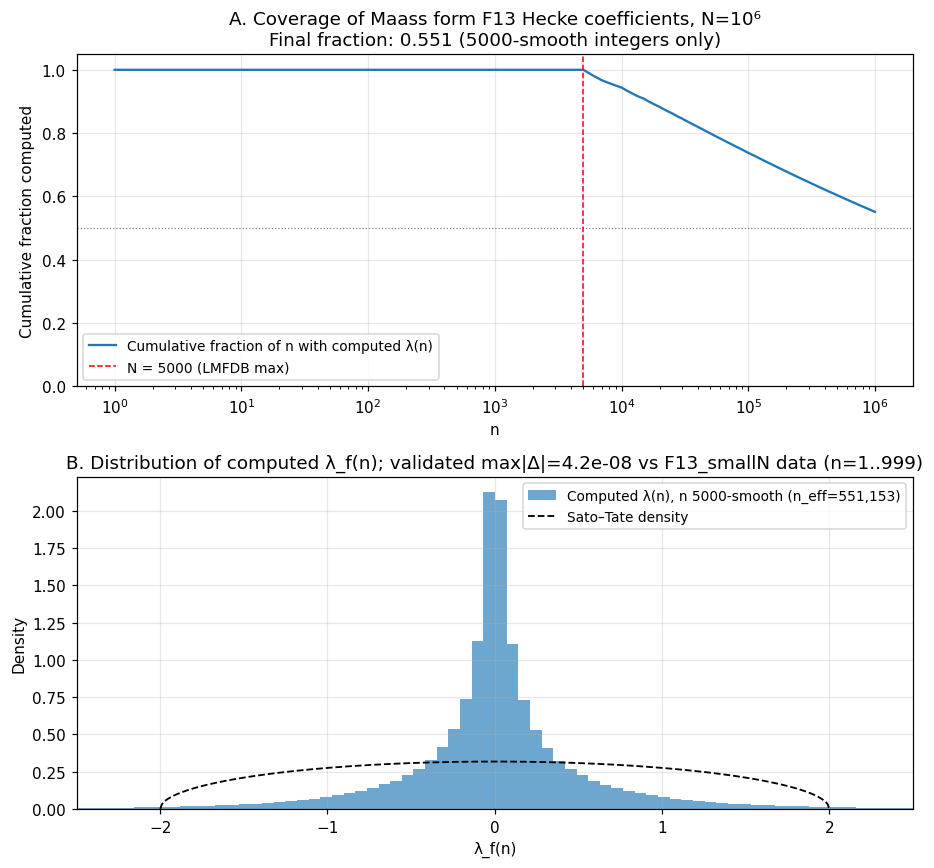

In [33]:
# Final figure: summary of the partial computation
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.5, 8.0))

# Subfigure A: cumulative coverage of computed lambda(n) up to N
mask = ~np.isnan(lam[1:N_target+1])
n_axis = np.arange(1, N_target+1)
cum_computed = np.cumsum(mask) / np.arange(1, N_target+1)

ax1.plot(n_axis[::1000], cum_computed[::1000], color='C0', lw=1.5, label='Cumulative fraction of n with computed λ(n)')
ax1.axhline(0.5, color='gray', ls=':', lw=0.8)
ax1.axvline(5000, color='red', ls='--', lw=1, label='N = 5000 (LMFDB max)')
ax1.set_xscale('log')
ax1.set_xlabel('n')
ax1.set_ylabel('Cumulative fraction computed')
ax1.set_title('A. Coverage of Maass form F13 Hecke coefficients, N=10⁶\n'
 f'Final fraction: {mask.mean():.3f} (5000-smooth integers only)')
ax1.set_ylim(0, 1.05)
ax1.legend(loc='lower left', fontsize=9)
ax1.grid(alpha=0.3)

# Subfigure B: histogram of computed λ(n) (Sato-Tate-like) — comparison vs validation values
vals = lam[1:N_target+1][mask]
ax2.hist(vals, bins=120, density=True, color='C0', alpha=0.65, label=f'Computed λ(n), n 5000-smooth (n_eff={len(vals):,})')
# Sato-Tate density: (1/pi) sqrt(1 - x^2/4), |x|<=2 (for normalized eigenvalues)
xx = np.linspace(-2, 2, 400)
st = (1/np.pi) * np.sqrt(np.clip(1 - (xx/2)**2, 0, None))
ax2.plot(xx, st, 'k--', lw=1.2, label='Sato–Tate density')
ax2.set_xlim(-2.5, 2.5)
ax2.set_xlabel('λ_f(n)')
ax2.set_ylabel('Density')
ax2.set_title(f'B. Distribution of computed λ_f(n); validated max|Δ|={np.max(np.abs(lam[1:1000]-a_F13[1:1000].real)):.1e} vs F13_smallN data (n=1..999)')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('F13_N1e6_partial_summary.png', dpi=130, bbox_inches='tight')
plt.show()
